<a href="https://colab.research.google.com/github/YHFTF/CV_HW-3/blob/main/CV_HW_3(A).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 불러오기 및, MLP 모델구조 정리

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

# GPU 가속 확인 (코랩에서 '런타임 유형 변경' -> T4 GPU 설정 권장)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. 데이터셋 로드 (Fashion-MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # -1 ~ 1 사이로 정규화
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. 기본 MLP 네트워크 구조 정의
class ExperimentAMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(ExperimentAMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),   # 입력층 -> 은닉층 1
            nn.ReLU(),
            nn.Linear(256, 128),          # 은닉층 1 -> 은닉층 2
            nn.ReLU(),
            nn.Linear(128, num_classes)   # 은닉층 2 -> 출력층 (Logits)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1) # 28x28 이미지를 784 1차원 벡터로 평탄화
        return self.net(x)

Using device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.8MB/s]


학습 루프 구현

In [ ]:
def run_experiment_a(loss_type='CrossEntropy', epochs=20, lr=0.001):
    print(f"\n[실험 A] {loss_type} 학습 시작")

    model = ExperimentAMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 보고서 작성을 위한 로그 기록용 리스트
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'grad_norms': [] # 기울기 소멸 증명용 그래디언트 크기 기록
    }

    # 손실 함수 설정
    if loss_type == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    elif loss_type == 'MSE':
        criterion = nn.MSELoss()

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        epoch_grad_norms = []

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)

            # [조건 분기] MSE는 원핫 인코딩 및 Softmax 적용 필요
            if loss_type == 'CrossEntropy':
                loss = criterion(outputs, targets)
            elif loss_type == 'MSE':
                outputs_softmax = torch.softmax(outputs, dim=1)
                targets_one_hot = F.one_hot(targets, num_classes=10).float()
                loss = criterion(outputs_softmax, targets_one_hot)

            loss.backward()

            # 그래디언트 크기(L2 Norm) 측정 - 기울기 소멸 분석용
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            epoch_grad_norms.append(total_norm ** 0.5)

            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        # 에폭별 평균값 계산
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = (correct / total) * 100
        epoch_mean_grad = np.mean(epoch_grad_norms)

        # 검증(Validation) 루프 - model.eval() 및 torch.no_grad() 필수 활용
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)

                if loss_type == 'CrossEntropy':
                    loss = criterion(outputs, targets)
                elif loss_type == 'MSE':
                    outputs_softmax = torch.softmax(outputs, dim=1)
                    targets_one_hot = F.one_hot(targets, num_classes=10).float()
                    loss = criterion(outputs_softmax, targets_one_hot)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()

        epoch_val_loss = val_loss / len(test_loader.dataset)
        epoch_val_acc = (val_correct / val_total) * 100

        # 로그 저장
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['grad_norms'].append(epoch_mean_grad)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | Grad Norm: {epoch_mean_grad:.6f}")

    print(f"소요 시간: {time.time() - start_time:.2f}초")
    return history

# 두 개의 실험 실행 및 결과 저장
ce_history = run_experiment_a(loss_type='CrossEntropy', epochs=20)
mse_history = run_experiment_a(loss_type='MSE', epochs=20)


[실험 A] CrossEntropy 학습 시작
Epoch [1/20] | Train Loss: 0.4965 | Val Acc: 84.57% | Grad Norm: 1.868567
Epoch [5/20] | Train Loss: 0.2817 | Val Acc: 87.74% | Grad Norm: 1.191330
Epoch [10/20] | Train Loss: 0.2171 | Val Acc: 88.07% | Grad Norm: 1.100653
Epoch [15/20] | Train Loss: 0.1734 | Val Acc: 88.91% | Grad Norm: 1.078448
Epoch [20/20] | Train Loss: 0.1393 | Val Acc: 88.65% | Grad Norm: 1.066408
소요 시간: 331.82초

[실험 A] MSE 학습 시작
Epoch [1/20] | Train Loss: 0.0259 | Val Acc: 84.15% | Grad Norm: 0.089835
Epoch [5/20] | Train Loss: 0.0160 | Val Acc: 87.34% | Grad Norm: 0.062435
Epoch [10/20] | Train Loss: 0.0132 | Val Acc: 87.88% | Grad Norm: 0.059138
Epoch [15/20] | Train Loss: 0.0113 | Val Acc: 88.45% | Grad Norm: 0.057644
Epoch [20/20] | Train Loss: 0.0099 | Val Acc: 88.72% | Grad Norm: 0.058023
소요 시간: 334.19초


정량 비교 및 그래프 출력


실험 항목           | 최종 검증 정확도(%) | Loss 최솟값   | 수렴 속도(Val Acc 80% 달성 Epoch)
---------------------------------------------------------------------------
CrossEntropy    | 88.65%           | 0.3305       | 1                   
MSE (w/ Softmax) | 88.72%           | 0.0172       | 1                   


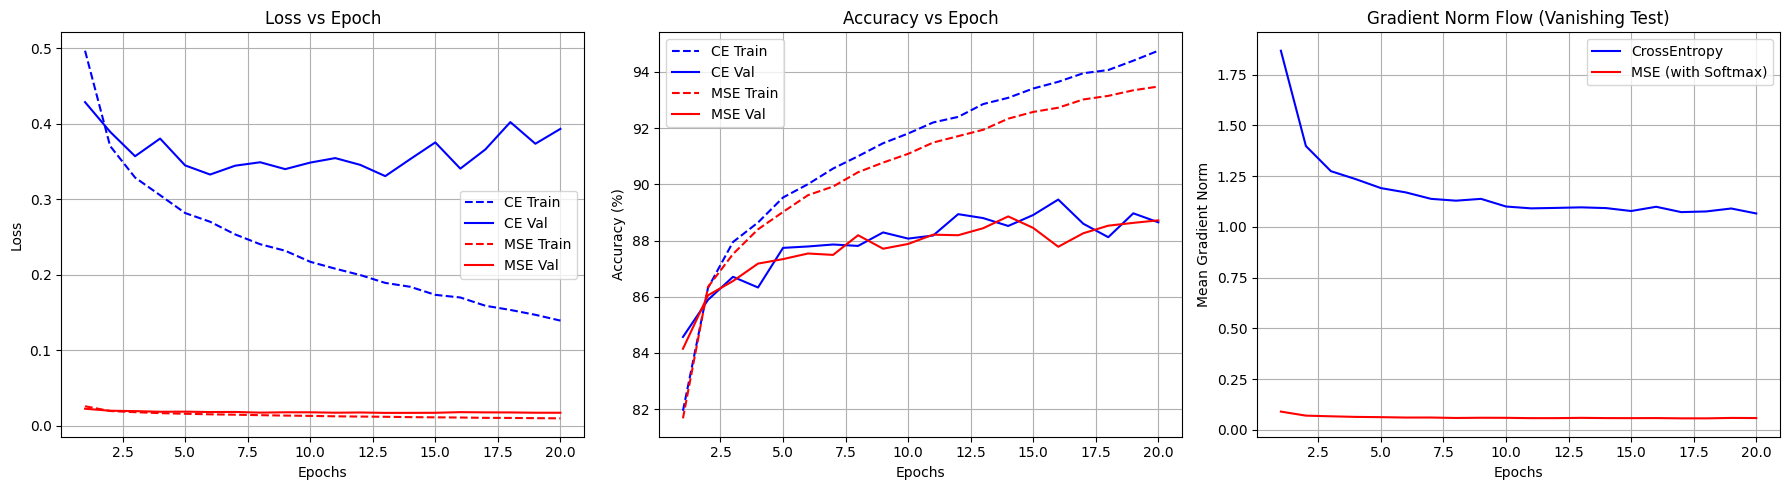

In [ ]:
# 1. 정량 비교 결과 표 출력
print("\n" + "="*50)
print(f"{'실험 항목':<15} | {'최종 검증 정확도(%)':<12} | {'Loss 최솟값':<10} | {'수렴 속도(Val Acc 80% 달성 Epoch)':<20}")
print("-"*75)

def get_converge_epoch(acc_list, threshold=80.0):
    for idx, acc in enumerate(acc_list):
        if acc >= threshold:
            return idx + 1
    return "미달성"

ce_conv = get_converge_epoch(ce_history['val_acc'])
mse_conv = get_converge_epoch(mse_history['val_acc'])

print(f"{'CrossEntropy':<15} | {ce_history['val_acc'][-1]:.2f}%{'' : <10} | {min(ce_history['val_loss']):.4f}{'' : <6} | {ce_conv:<20}")
print(f"{'MSE (w/ Softmax)':<15} | {mse_history['val_acc'][-1]:.2f}%{'' : <10} | {min(mse_history['val_loss']):.4f}{'' : <6} | {mse_conv:<20}")
print("="*50)

# 2. 그래프 시각화 (Loss, Accuracy, Gradient Norm)
epochs_range = range(1, 21)

plt.figure(figsize=(18, 5))

# Loss 곡선
plt.subplot(1, 3, 1)
plt.plot(epochs_range, ce_history['train_loss'], 'b--', label='CE Train')
plt.plot(epochs_range, ce_history['val_loss'], 'b', label='CE Val')
plt.plot(epochs_range, mse_history['train_loss'], 'r--', label='MSE Train')
plt.plot(epochs_range, mse_history['val_loss'], 'r', label='MSE Val')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy 곡선
plt.subplot(1, 3, 2)
plt.plot(epochs_range, ce_history['train_acc'], 'b--', label='CE Train')
plt.plot(epochs_range, ce_history['val_acc'], 'b', label='CE Val')
plt.plot(epochs_range, mse_history['train_acc'], 'r--', label='MSE Train')
plt.plot(epochs_range, mse_history['val_acc'], 'r', label='MSE Val')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Gradient Norm 곡선 (기울기 소멸 증명 지표)
plt.subplot(1, 3, 3)
plt.plot(epochs_range, ce_history['grad_norms'], 'b', label='CrossEntropy')
plt.plot(epochs_range, mse_history['grad_norms'], 'r', label='MSE (with Softmax)')
plt.title('Gradient Norm Flow (Vanishing Test)')
plt.xlabel('Epochs')
plt.ylabel('Mean Gradient Norm')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()